In [ ]:
!pip install -U datasets fsspec
!pip install tueplots
!sudo apt install cm-super dvipng texlive-latex-extra texlive-latex-recommended
!pip install --upgrade transformers

In [1]:
import numpy as np
from datasets import load_dataset
import re, random, torch
from collections import Counter
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tueplots import figsizes, fontsizes, fonts, bundles, cycler
from tueplots.constants.color import palettes
from random import randint
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, TrainingArguments, Trainer

RANDOM_SEED=42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_SEED)

I define helper methods above everything else to give a better reading-flow through the notebook

In [2]:
def clean_txt(text):
    """
    Cleans text for NLP pipeline by removing HTML tags

    :param text: The text that is supposed to be preprocessed.
    :return: Text without HTML-tags
    """
    return re.sub(r"<.*?>", " ", text)


def plot_top_ngrams(train_ngrams, test_ngrams):
    plt.rcParams.update(bundles.icml2022(column="full", nrows=2, ncols=3))
    plt.rcParams.update({"figure.dpi": 350})

    fig, axs = plt.subplots(1, 3)

    titles = ["Unigrams", "Bigrams", "Trigrams"]

    for ax, ngram_type, title in zip(axs.flat, ['unigrams', 'bigrams', 'trigrams'], titles):
        train_tokens, train_counts = train_ngrams[ngram_type]
        test_tokens, test_counts = test_ngrams[ngram_type]

        bar_width = 1
        group_spacing = 3.5

        # Interleave train/test bars
        x_train = []
        x_test = []
        xticks = []
        xticklabels = []

        for i in range(10):
            center = i * group_spacing
            x_train.append(center - bar_width / 2)
            x_test.append(center + bar_width / 2)

            xticks.append(center)
            xticklabels.append(f"{train_tokens[i]}\n{test_tokens[i]}")

        # Plot bars
        ax.bar(x_train, train_counts, width=bar_width, color='skyblue', label='Train')
        ax.bar(x_test, test_counts, width=bar_width, color='salmon', label='Test')

        ax.set_title(title)
        ax.set_ylabel("Frequency")
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticklabels, rotation=80)
        ax.legend()

    plt.suptitle("Top 10 N-grams in Training and Test Sets")
    plt.show()


def create_conf_matrix(y, y_hat):
    plt.rcParams.update(bundles.icml2022(column="full", nrows=1, ncols=1))
    plt.rcParams.update({"figure.dpi": 350})
    fig, axs = plt.subplots(nrows=1, ncols=2, gridspec_kw={'width_ratios': [1, 1]}, constrained_layout=True)
    cm = confusion_matrix(y, y_hat)
    cm_normalized = cm / cm.sum(axis=1, keepdims=True) # The sum is row-wise

    disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Positive", "Negative"])
    disp_cm.plot(cmap="Blues", ax=axs[0], xticks_rotation='horizontal', colorbar=False, values_format=None)
    axs[0].set_title('Confusion Matrix') #, fontsize=10

    disp_cm_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=["Positive", "Negative"])
    im = disp_cm_norm.plot(cmap="Blues", ax=axs[1], xticks_rotation='horizontal', colorbar=False, values_format=None)
    axs[1].set_title('Normalized Confusion Matrix') #, fontsize=10

    cbar = fig.colorbar(im.im_, ax=axs, location='right', shrink=0.605, aspect=15, pad=0.05, norm=mcolors.Normalize(vmin=0, vmax=1))
    cbar.set_label("Frequency")

    plt.show()

def create_conf_matrix_for_model_comparison(y_test_m1, y_hat_m1, y_test_m2, y_hat_m2):
    plt.rcParams.update(bundles.icml2022(column="full", nrows=1, ncols=1))
    plt.rcParams.update({"figure.dpi": 350})
    fig, axs = plt.subplots(nrows=1, ncols=2, gridspec_kw={'width_ratios': [1, 1]}, constrained_layout=True)

    cm_m1 = confusion_matrix(y_test_m1, y_hat_m1)
    cm_m1_normalized = cm_m1 / cm_m1.sum(axis=1, keepdims=True) # The sum is row-wise

    cm_m2 = confusion_matrix(y_test_m2, y_hat_m2)
    cm_m2_normalized = cm_m2 / cm_m2.sum(axis=1, keepdims=True) # The sum is row-wise

    disp_m1 = ConfusionMatrixDisplay(confusion_matrix=cm_m1_normalized, display_labels=["Positive", "Negative"])
    disp_m1.plot(cmap="Blues", ax=axs[0], xticks_rotation='horizontal', colorbar=False,
                 values_format=None)
    axs[0].set_title('TFIDF + Logistic Regression') #, fontsize=10

    disp_m2 = ConfusionMatrixDisplay(confusion_matrix=cm_m2_normalized, display_labels=["Positive", "Negative"])
    im = disp_m2.plot(cmap="Blues", ax=axs[1], xticks_rotation='horizontal', colorbar=False,
                      values_format=None)
    axs[1].set_title('DistillBERT') #, fontsize=10

    cbar = fig.colorbar(im.im_, ax=axs, location='right', shrink=0.605, aspect=15, pad=0.05, norm=mcolors.Normalize(vmin=0, vmax=1))
    cbar.set_label("Frequency")

    plt.show()

The given command to show datasets doesn't work for me, so I'll use the example given in the task, i.e. I'll use the "IMDB" dataset and try to do sentiment classification.

# Binary Sentiment Classification with the IMDB Dataset

## Step 1 - Reading the Dataset

The IMDB dataset consists of movie reviews (column "text") with corresponding sentiments (column "label"). Sentiments are either 0, indicating a negative review or 1, indicating a positive review.

**The task:** Sentiment classification has the goal of classifying an input (e.g. a text, movie review, ...) into multiple levels of emotion. The sentiment can be encoded in many different granularities of emotion which can include negative, neural or positive sentiment (e.g. -1, 0, 1) or a score between 0 and 100 or **binary** which just includes the negative and positive label (encoded as 0 and 1), like it was done in the IMDB dataset.

**The dataset:** The IMDB dataset consists of movie review and a label that binarily ($=\{0,1\}$) encodes whether the corresponding movie review is positive or negative.
- Split: The dataset is split into train, test and unsupervised data points
    - Train split: contains $25.000$ labeled data points
    - Test split: contains $25.000$ labeled data points
    - Unsupervised split: contains $50.000$ unlabeled data points.
- Each annotated split is perfectly balanced, meaning that among the 25.000 instances, there 50% belong to either class.
- General structure: Each split contains data instances in the form of dictionaries. Each instace-dictionary is structured into
    - "text": Contains the movie review
    - "label": Contains the sentiment of the corresponding movie review. 0 encodes a negative and 1 a positive review


In [3]:
# Load the dataset
dataset = load_dataset("imdb")
train_data = dataset["train"]
test_data = dataset["test"]

# Extract texts and labels
X_train_m1, y_train_m1 = train_data["text"], train_data["label"]
X_test_m1, y_test_m1 = test_data["text"], test_data["label"]

Look at the general structure of the dataset

In [4]:
print(f"Dataset:\n"
      f"{dataset}"
      f"\n\n")

Dataset:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})




In [5]:
print("Train size:", len(train_data))
print("Test size:", len(test_data))

Train size: 25000
Test size: 25000


Here are some random samples (reviews) and their sentiments (0 = negative, 1 = positive)

In [7]:
for _ in range(3):
    i = randint(0, len(train_data))
    print(f"Sample {i} text:\n"
        f"{train_data[i]['text']}\n\n"
        f"Sample {i} label: {train_data[i]['label']}\n\n" + "---" * 10)

Sample 20952 text:
Arguably this is a very good "sequel", better than the first live action film 101 Dalmatians. It has good dogs, good actors, good jokes and all right slapstick! <br /><br />Cruella DeVil, who has had some rather major therapy, is now a lover of dogs and very kind to them. Many, including Chloe Simon, owner of one of the dogs that Cruella once tried to kill, do not believe this. Others, like Kevin Shepherd (owner of 2nd Chance Dog Shelter) believe that she has changed. <br /><br />Meanwhile, Dipstick, with his mate, have given birth to three cute dalmatian puppies! Little Dipper, Domino and Oddball...<br /><br />Starring Eric Idle as Waddlesworth (the hilarious macaw), Glenn Close as Cruella herself and Gerard Depardieu as Le Pelt (another baddie, the name should give a clue), this is a good family film with excitement and lots more!! One downfall of this film is that is has a lot of painful slapstick, but not quite as excessive as the last film. This is also funnier 

**Interesting findings in this dataset:** It contains HTML code, which we need to remove (e.g. \<br\/\>\<br\/\>)

## Step 2: Preprocessing
This cleaning step only includes removing HTML tags, as the other preprocessing steps are handled by the TfidfVectorizer and the Distilbert tokenizer respectively for each model.

In [6]:
sample_before_clean = X_train_m1[0]
X_train_m1 = [clean_txt(t) for t in X_train_m1]
X_test_m1 = [clean_txt(t) for t in X_test_m1]

Here is a little example of a cleaned text

In [7]:
print(f"Sample text before cleaning: {sample_before_clean}\n\n"
      f"Sample text after cleaning: {X_train_m1[0]}")

Sample text before cleaning: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes

## Step 3: Analysis, Dataset Statistics

**Document count ** was shown earlier in this script. Document count is 25.000 each for the train and test split. The **label count** is shown here. Both splits are class balanced, meaning there are 12.500 documents that belong to each class in each split.

I use two models. BERT and TfidfVectorizer + Logistic Regression. For the dataset statistics, I will use the latter, as BERT's tokenizer uses sub-word tokenizations.

According to the docs, TfidfVectorizer = CountVectorizer followed by a TfidfTransformer. This means that a CountVectorizer can be used to compute metrics like the unigram-, bigram-counts.

I won't use this CountVectorizer when training the logistic regression model because I want to make the code cleaner, so I'll train a TfidfVectorizer, even though I could re-use it and then apply a TfidfTransformer, this is equivalent, and I think that retraining the same model on the same data will yield almost the exact same results due to the nature of the CountVectorizer+TfidfTransformer/ TfidfVectorizer here. The biggest difference is that I cap the maximum number of features as a regularizer later on. This improves accuracy by around 2%.

From counting the labels, we can see that the dataset is class-balanced. This means that the number of instances for each class (positive and negative) is equal.

Train as well as test splits are perfectly balanced.

In [8]:
labels = [d["label"] for d in train_data]
label_counts = Counter(labels)
print(f"Train label counts: {label_counts}\n"
      f"    0 = negative: {label_counts[0]} instances\n"
      f"    1 = positive: {label_counts[1]} instances")

labels = [d["label"] for d in test_data]
label_counts = Counter(labels)
print(f"Test label counts: {label_counts}\n"
      f"    0 = negative: {label_counts[0]} instances\n"
      f"    1 = positive: {label_counts[1]} instances")

Train label counts: Counter({0: 12500, 1: 12500})
    0 = negative: 12500 instances
    1 = positive: 12500 instances
Test label counts: Counter({0: 12500, 1: 12500})
    0 = negative: 12500 instances
    1 = positive: 12500 instances


This cell helps to extract statistics about Unigrams, Bigrams and Trigrams!

In [9]:
def extract_ngram_stats(texts, n):
    """Extract n-gram vocabulary size and total frequency for a given n"""
    vectorizer = CountVectorizer(ngram_range=(n, n), stop_words="english", lowercase=True)
    X = vectorizer.fit_transform(texts)

    vocab = vectorizer.get_feature_names_out()
    total_count = X.sum()  # total number of n-gram occurrences

    return {
        "n": n,
        "vocab_size": len(vocab),
        "total_count": total_count,
        "vectorizer": vectorizer,
        "X": X
    }

# Apply to training data
train_unigrams  = extract_ngram_stats(X_train_m1, 1)
train_bigrams   = extract_ngram_stats(X_train_m1, 2)
train_trigrams  = extract_ngram_stats(X_train_m1, 3)
test_unigrams  = extract_ngram_stats(X_test_m1, 1)
test_bigrams   = extract_ngram_stats(X_test_m1, 2)
test_trigrams  = extract_ngram_stats(X_test_m1, 3)

Look at the Uni-, Bi-, and Trigrams with the highest frequencies

In [10]:
def get_top_ngrams(vectorizer, X, n=10):
    counts = X.sum(axis=0).A1
    vocab = vectorizer.get_feature_names_out()
    sorted_idxs = np.argsort(counts)[::-1][:n]
    return "\n  ".join([f"({vocab[i]}, {counts[i]})" for i in sorted_idxs])

def get_top_ngrams(vectorizer, X, n=10):
    """Returns top n n-grams and their counts as lists for plotting."""
    counts = X.sum(axis=0).A1
    vocab = vectorizer.get_feature_names_out()
    sorted_idxs = np.argsort(counts)[::-1][:n]
    top_ngrams = [vocab[i] for i in sorted_idxs]
    top_counts = [counts[i] for i in sorted_idxs]
    return top_ngrams, top_counts

top_train_unigrams, top_train_unigram_counts = get_top_ngrams(train_unigrams['vectorizer'], train_unigrams['X'])
top_train_bigrams, top_train_bigram_counts  = get_top_ngrams(train_bigrams['vectorizer'], train_bigrams['X'])
top_train_trigrams, top_train_trigram_counts = get_top_ngrams(train_trigrams['vectorizer'], train_trigrams['X'])
top_test_unigrams, top_test_unigram_counts = get_top_ngrams(test_unigrams['vectorizer'], test_unigrams['X'])
top_test_bigrams, top_test_bigram_counts  = get_top_ngrams(test_bigrams['vectorizer'], test_bigrams['X'])
top_test_trigrams, top_test_trigram_counts = get_top_ngrams(test_trigrams['vectorizer'], test_trigrams['X'])

print("Top train unigrams:\n ", "\n  ".join([f"({ngram}, {count})" for ngram, count in zip(top_train_unigrams, top_train_unigram_counts)]), "\n")
print("Top train bigrams:\n ", "\n  ".join([f"({ngram}, {count})" for ngram, count in zip(top_train_bigrams, top_train_bigram_counts)]), "\n")
print("Top train trigrams:\n ", "\n  ".join([f"({ngram}, {count})" for ngram, count in zip(top_train_trigrams, top_train_trigram_counts)]), "\n")

Top train unigrams:
  (movie, 44046)
  (film, 40159)
  (like, 20281)
  (just, 17773)
  (good, 15147)
  (time, 12726)
  (story, 11988)
  (really, 11738)
  (bad, 9308)
  (people, 9287) 

Top train bigrams:
  (ve seen, 2121)
  (special effects, 1114)
  (don know, 1082)
  (low budget, 882)
  (year old, 876)
  (looks like, 854)
  (waste time, 800)
  (movie just, 776)
  (good movie, 756)
  (new york, 744) 

Top train trigrams:
  (don waste time, 214)
  (movie ve seen, 205)
  (new york city, 164)
  (movies ve seen, 154)
  (film ve seen, 123)
  (world war ii, 107)
  (films ve seen, 106)
  (worst movie seen, 104)
  (does good job, 100)
  (did great job, 99) 



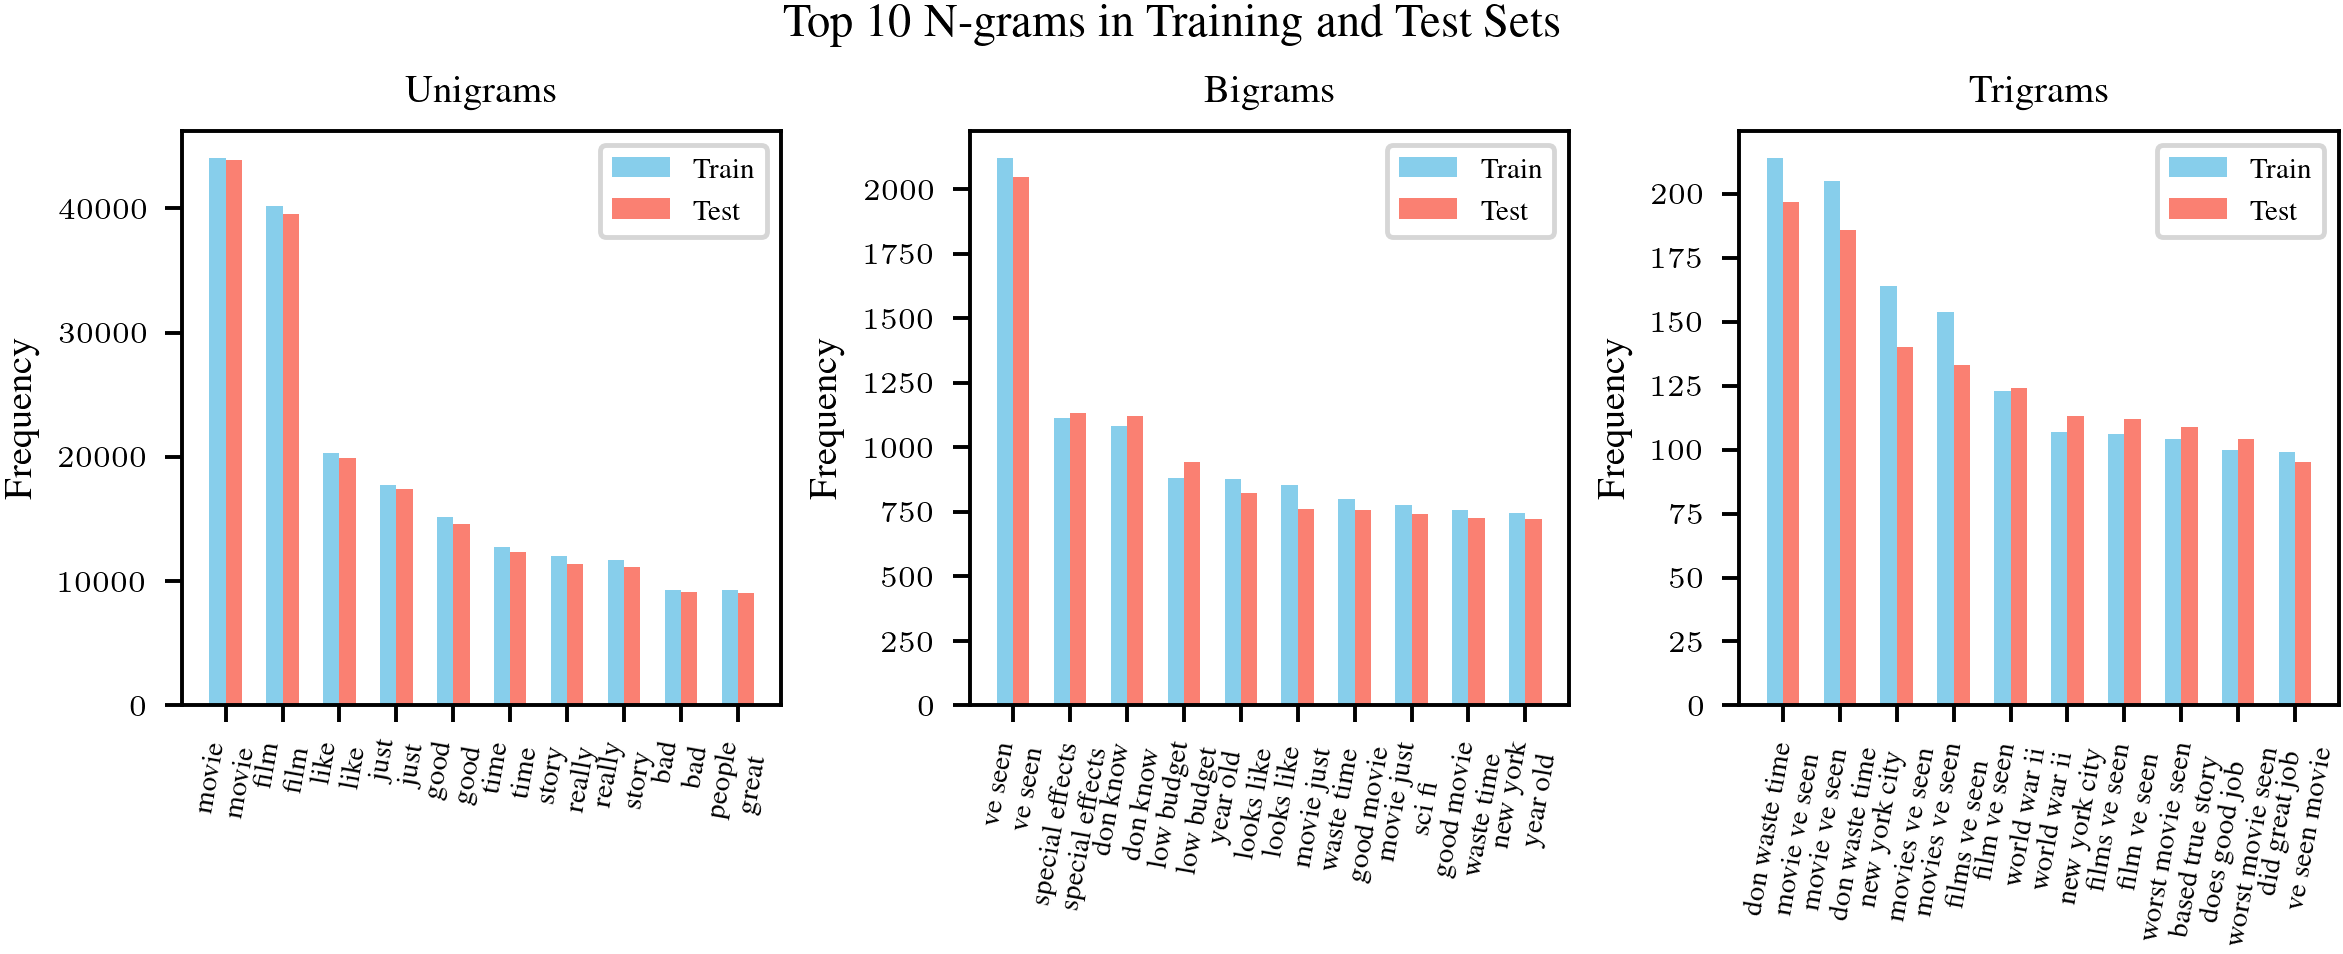

In [11]:
train_ngrams = {
    "unigrams": (top_train_unigrams, top_train_unigram_counts),
    "bigrams":  (top_train_bigrams, top_train_bigram_counts),
    "trigrams": (top_train_trigrams, top_train_trigram_counts)
}

test_ngrams = {
    "unigrams": (top_test_unigrams, top_test_unigram_counts),
    "bigrams":  (top_test_bigrams, top_test_bigram_counts),
    "trigrams": (top_test_trigrams, top_test_trigram_counts)
}

plot_top_ngrams(train_ngrams, test_ngrams)

Compare the total number of n-grams and resulting vocabulary sizes when tokenizing with the respective n.

In [12]:
print(f"Unigram count: {train_unigrams['vocab_size']}\n"
      f"Bigram count:  {train_bigrams['vocab_size']}\n"
      f"Trigram count: {train_trigrams['vocab_size']}\n\n"
      f"Token count/ Total number of unigrams: {train_unigrams['total_count']}\n"
      f"Total number of bigrams:  {train_bigrams['total_count']}\n"
      f"Total number of trigrams: {train_trigrams['total_count']}\n")

Unigram count: 74532
Bigram count:  1697400
Trigram count: 2535597

Token count/ Total number of unigrams: 2701996
Total number of bigrams:  2676996
Total number of trigrams: 2651996



**Interesting**: The vocab of Bigrams is ~22.7 times as large as the vocabulary of Unigrams, But the vocabulary of Trigrams is ~34 times as large as the one of Unigrams, so the increase in vocabulary size is not linear.

**Another interesting thing**: The total number of unigrams - 25.000 = total number of bigrams - 25.000 = total number of trigrams. <br>
This is because n-grams are created with sliding windows, so a review with $T$ tokens produces $T$ unigrams, $T-1$ bigrams and $T-2$ trigrams. With 25.000 documents, this explains the number of trigrams which is $(T-2)*25.000$, resulting in a difference of $50.000$ trigrams, compared to unigrams.

**Token count**: Look at the total number of tokens **after processing and tokenizing** and how many tokens each text has on average after this process

In [13]:
# Compute n-gram counts for each document. 'X' contains the transformed texts and axis=1 means we sum each text separetely
unigram_doc_lengths = train_unigrams['X'].sum(axis=1).A1
bigram_doc_lengths = train_bigrams['X'].sum(axis=1).A1
trigram_doc_lengths = train_trigrams['X'].sum(axis=1).A1

# Average the lengths of the tokenized documents
avg_unigrams_per_doc = unigram_doc_lengths.mean()
avg_bigrams_per_doc  = bigram_doc_lengths.mean()
avg_trigrams_per_doc = trigram_doc_lengths.mean()

print(f"Average number of unigrams per review in the train dataset: {avg_unigrams_per_doc:.2f}")
print(f"Average number of bigrams  per review in the train dataset: {avg_bigrams_per_doc:.2f}")
print(f"Average number of trigrams per review in the train dataset: {avg_trigrams_per_doc:.2f}")

Average number of unigrams per review in the train dataset: 108.08
Average number of bigrams  per review in the train dataset: 107.08
Average number of trigrams per review in the train dataset: 106.08


## Model 1 - Step 4, 5 & 6: Train a Logistic Regression model based on TF-IDF vectors
This approach uses TF-IDF as an input metric. There, the input documents (reviews) are transformed with 2 metrics.
- Term Frequency (TF): The number of times that a term t occurs in the given document divided by the total number of terms in the document <br>
$$TF(t,d) = \frac{\text{Number of times t appears in d}}{\text{Number of terms in d}}$$
- Inverse Document Frequency (IDF): The logarithm of the total number of documents in the (train) dataset (also called corpus D) divided by the number of documents that contain the word t. <br>
$$IDF(t,D) = log\left(\frac{\text{Number of Documents in D}}{\text{Number of Documents containing t}}\right)$$
- $\operatorname{TF-IDF}(t,d,D) = TF(t,d) \cdot IDF(t,D)$
where:
- $t$: A certain word/ term, e.g. House, Fish, ...
- $d$: A certain document, i.e. a movie specific movie review in this case
- $D$: The corpus, i.e. the dataset that contains all movie reviews in this case


I use the **Accuracy** as one of the most expressive metrics. This is justified, as there are only 2 classes here (many classes make it harder to have a high accuracy, "close" predictions are also ignored) and the data splits are class-balanced. I also compute **confusion matrices**, as they neatly visualize the False positives and False negatives. I also show the **F1 score** as it captures the tradeoff between the false positives and false negatives.

The TfidfVectorizer preprocesses and tokenizes our movie reviews:
- Lowercasing (lowercase=True)
- Stopword removal
- Punctuation removal
- tokenization (uses a regex tokenizer (\b\w\w+\b) by default)

and returns a sparse matrix output

For regularization, the max_features are set to 15.000, meaning that only the top 15.000 features ranked by the frequency are kept and all others are completely discarded.

In [15]:
# Build Pipeline with TF-IDF and Logistic Regression
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=15000, lowercase=True, ngram_range=(1,3))),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))
])

# Train model
pipeline.fit(X_train_m1, y_train_m1)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=15000, ngram_range=(1, 3),
                                 stop_words='english')),
                ('clf', LogisticRegression(max_iter=1000, random_state=42))])

Accuracy: 0.8832

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.88      0.88     12500
    Positive       0.88      0.89      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



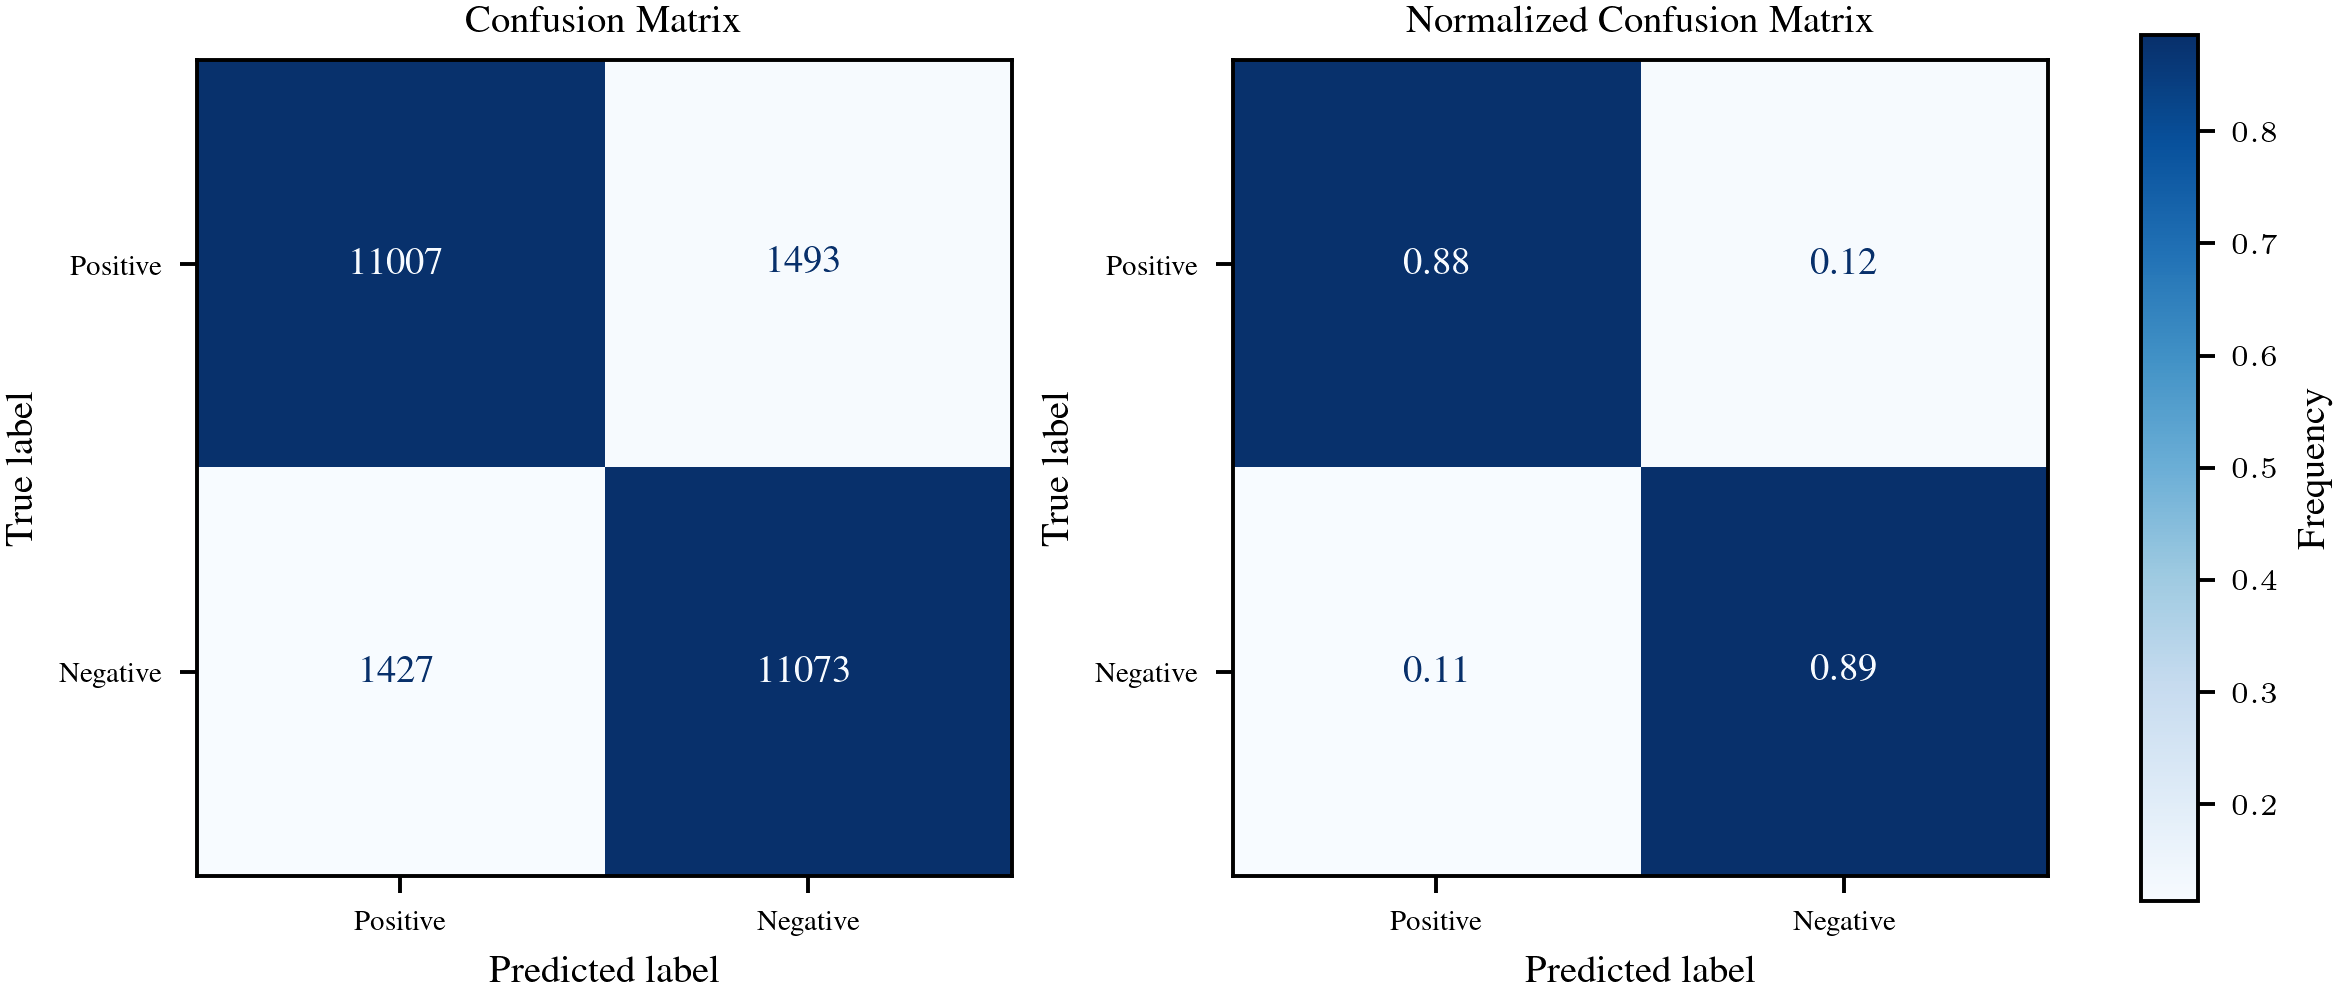

In [16]:
# Predict on test set
y_hat_m1 = pipeline.predict(X_test_m1)

# Evaluate
accuracy = accuracy_score(y_test_m1, y_hat_m1)
print(f"Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test_m1, y_hat_m1, target_names=["Negative", "Positive"]))

create_conf_matrix(y_test_m1, y_hat_m1)

# Model 2 - Step 4 & 5: Use a version of BERT (Distilbert) for sentiment classification

BERT is model that is known to be good at understanding the context of words by analyzing relationships between them in both directions in a sentence. I use DistilBERT, as this is a knowledge-distilled model, meaning it's smaller with faster inference. I couldn't run BERT on my laptop.

The tokenizer of BERT is based on WordPiece. This is a sub-word tokenization method, which means that the smalles units of the tokenized texts are not words but rather parts  of words (sub-words)

Here, we use the train_data (which consists of dictionaries with texts and labels) directly, so we need to clean that again, as we previously just cleaned X_train and X_test. I coul've done the cleaning before extracting X_train and X_test but I feel like this matches the expected schema of the file better do do the cleaning in Step 2.

In [17]:
# Clean data again
train_data = train_data.map(lambda x: {"text": clean_txt(x["text"])})
test_data = test_data.map(lambda x: {"text": clean_txt(x["text"])})

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [18]:
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=512)

tokenized_train = train_data.map(tokenize, batched=True)
tokenized_train.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
tokenized_test = test_data.map(tokenize, batched=True)
tokenized_test.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [19]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=1e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    #num_train_epochs=1,
    max_steps=550,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    logging_strategy="steps",
    eval_steps=50,
    eval_strategy="steps",
    save_strategy="epoch",
    report_to="none",
    seed=RANDOM_SEED
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer
)

trainer.train()

<ipython-input-19-eff295948d22>:19: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss,Validation Loss
50,0.605100,0.562523
100,0.332700,0.292727
150,0.279600,0.260360
200,0.274000,0.251231
250,0.259800,0.232685
300,0.302500,0.227961
350,0.261900,0.227681
400,0.208300,0.232967
450,0.239800,0.224226
500,0.206700,0.219148


TrainOutput(global_step=550, training_loss=0.3042760547724637, metrics={'train_runtime': 5020.5937, 'train_samples_per_second': 3.506, 'train_steps_per_second': 0.11, 'total_flos': 2331426216345600.0, 'train_loss': 0.3042760547724637, 'epoch': 0.7033248081841432})

In [20]:
trainer.evaluate()

{'eval_loss': 0.22295786440372467,
 'eval_runtime': 381.6869,
 'eval_samples_per_second': 65.499,
 'eval_steps_per_second': 1.024,
 'epoch': 0.7033248081841432}

In [21]:
predictions = trainer.predict(tokenized_test)
print(predictions)

# Extract predicted class IDs
y_hat_m2 = np.argmax(predictions.predictions, axis=1)
y_test_m2 = predictions.label_ids

PredictionOutput(predictions=array([[ 1.9539514 , -1.8792511 ],
       [ 0.12397037, -0.05802039],
       [ 1.6737101 , -1.5830379 ],
       ...,
       [-0.6115532 ,  0.7944858 ],
       [-0.11401477,  0.1913974 ],
       [-1.0798631 ,  1.0720936 ]], dtype=float32), label_ids=array([0, 0, 0, ..., 1, 1, 1]), metrics={'test_loss': 0.22295786440372467, 'test_runtime': 383.9391, 'test_samples_per_second': 65.114, 'test_steps_per_second': 1.018})


Accuracy: 0.9130

Classification Report:
              precision    recall  f1-score   support

    Negative       0.93      0.89      0.91     12500
    Positive       0.90      0.93      0.91     12500

    accuracy                           0.91     25000
   macro avg       0.91      0.91      0.91     25000
weighted avg       0.91      0.91      0.91     25000



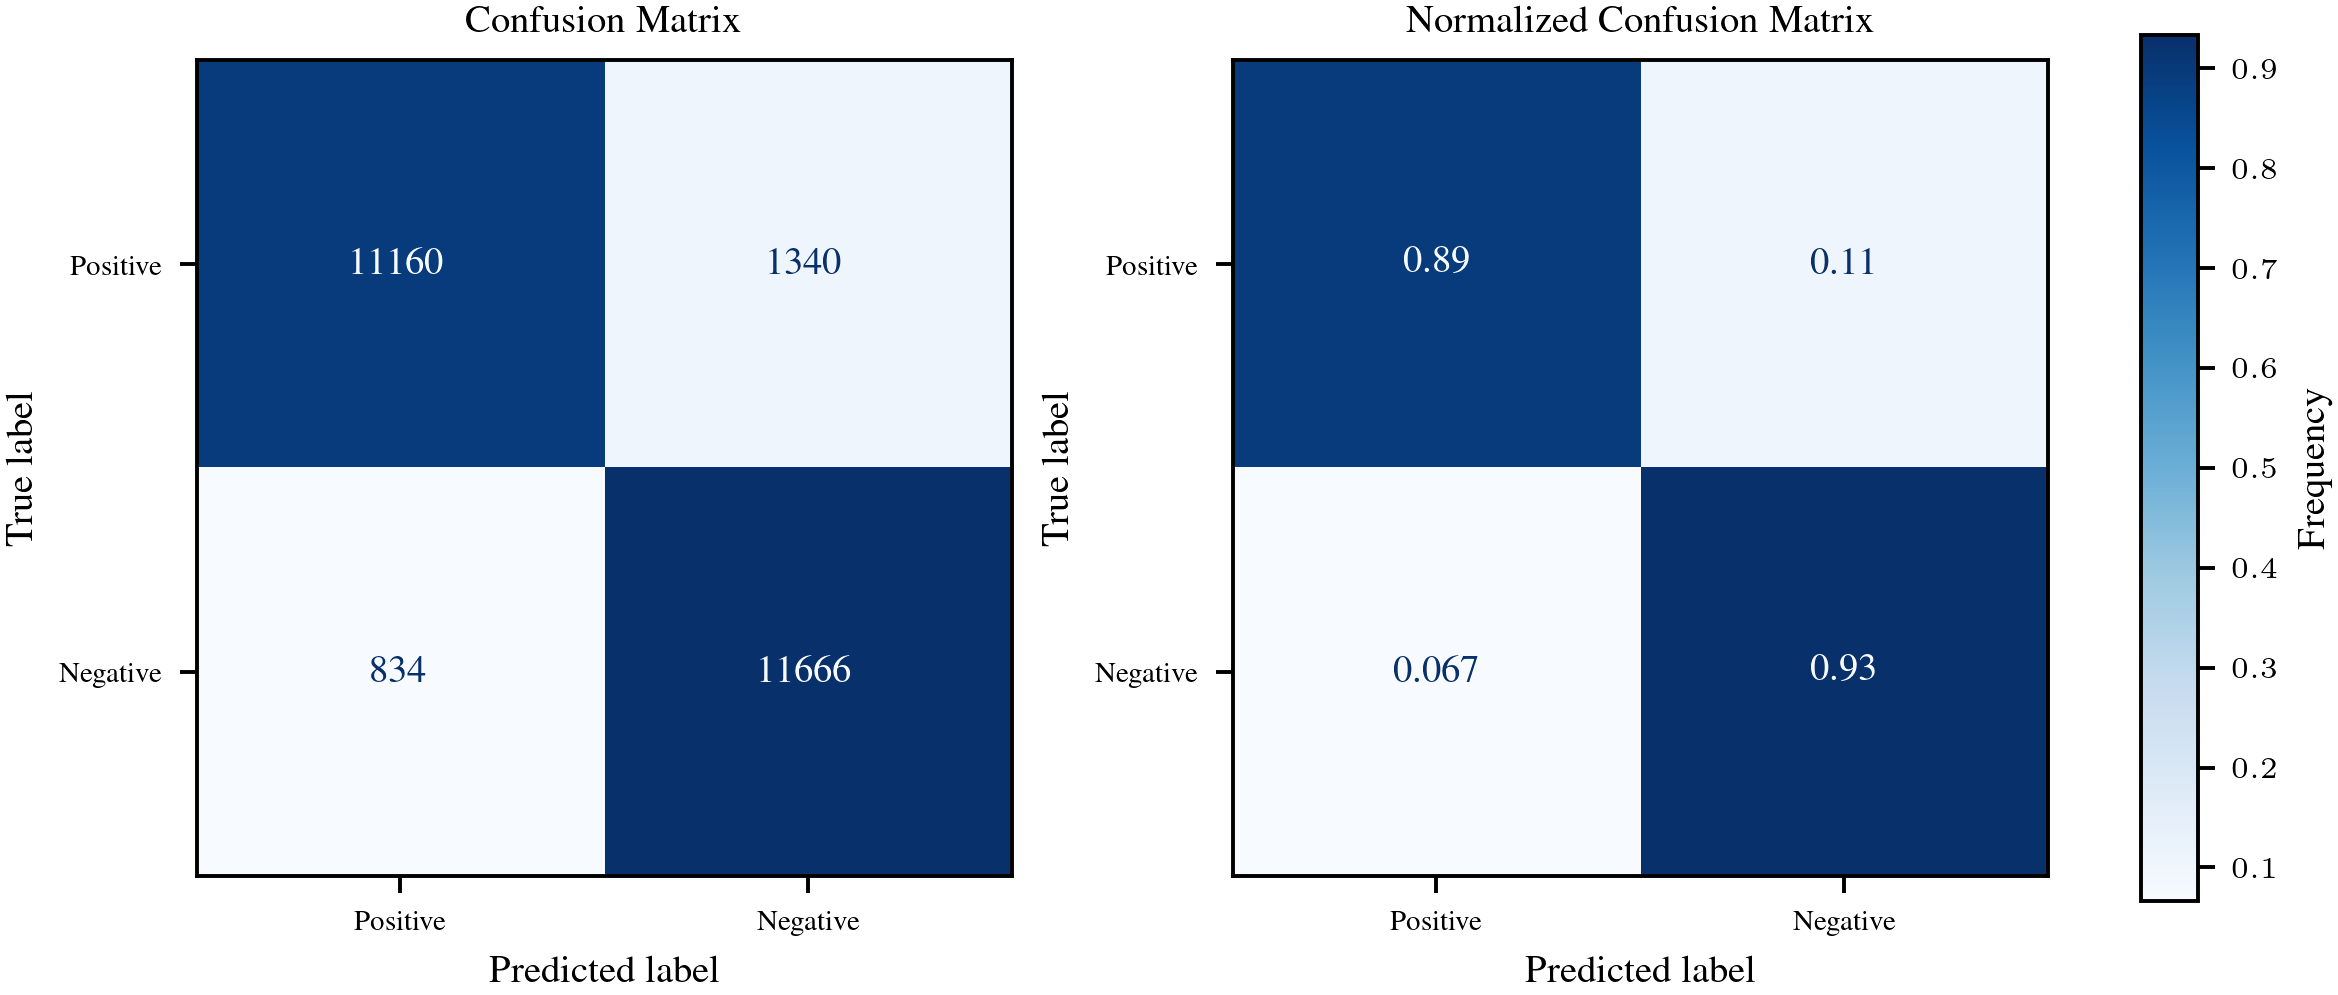

In [22]:
accuracy = accuracy_score(y_test_m2, y_hat_m2)
print(f"Accuracy: {accuracy:.4f}")

# 4. Classification Report
print("\nClassification Report:")
print(classification_report(y_test_m2, y_hat_m2, target_names=["Negative", "Positive"]))

create_conf_matrix(y_test_m2, y_hat_m2)

# Compare both models directly

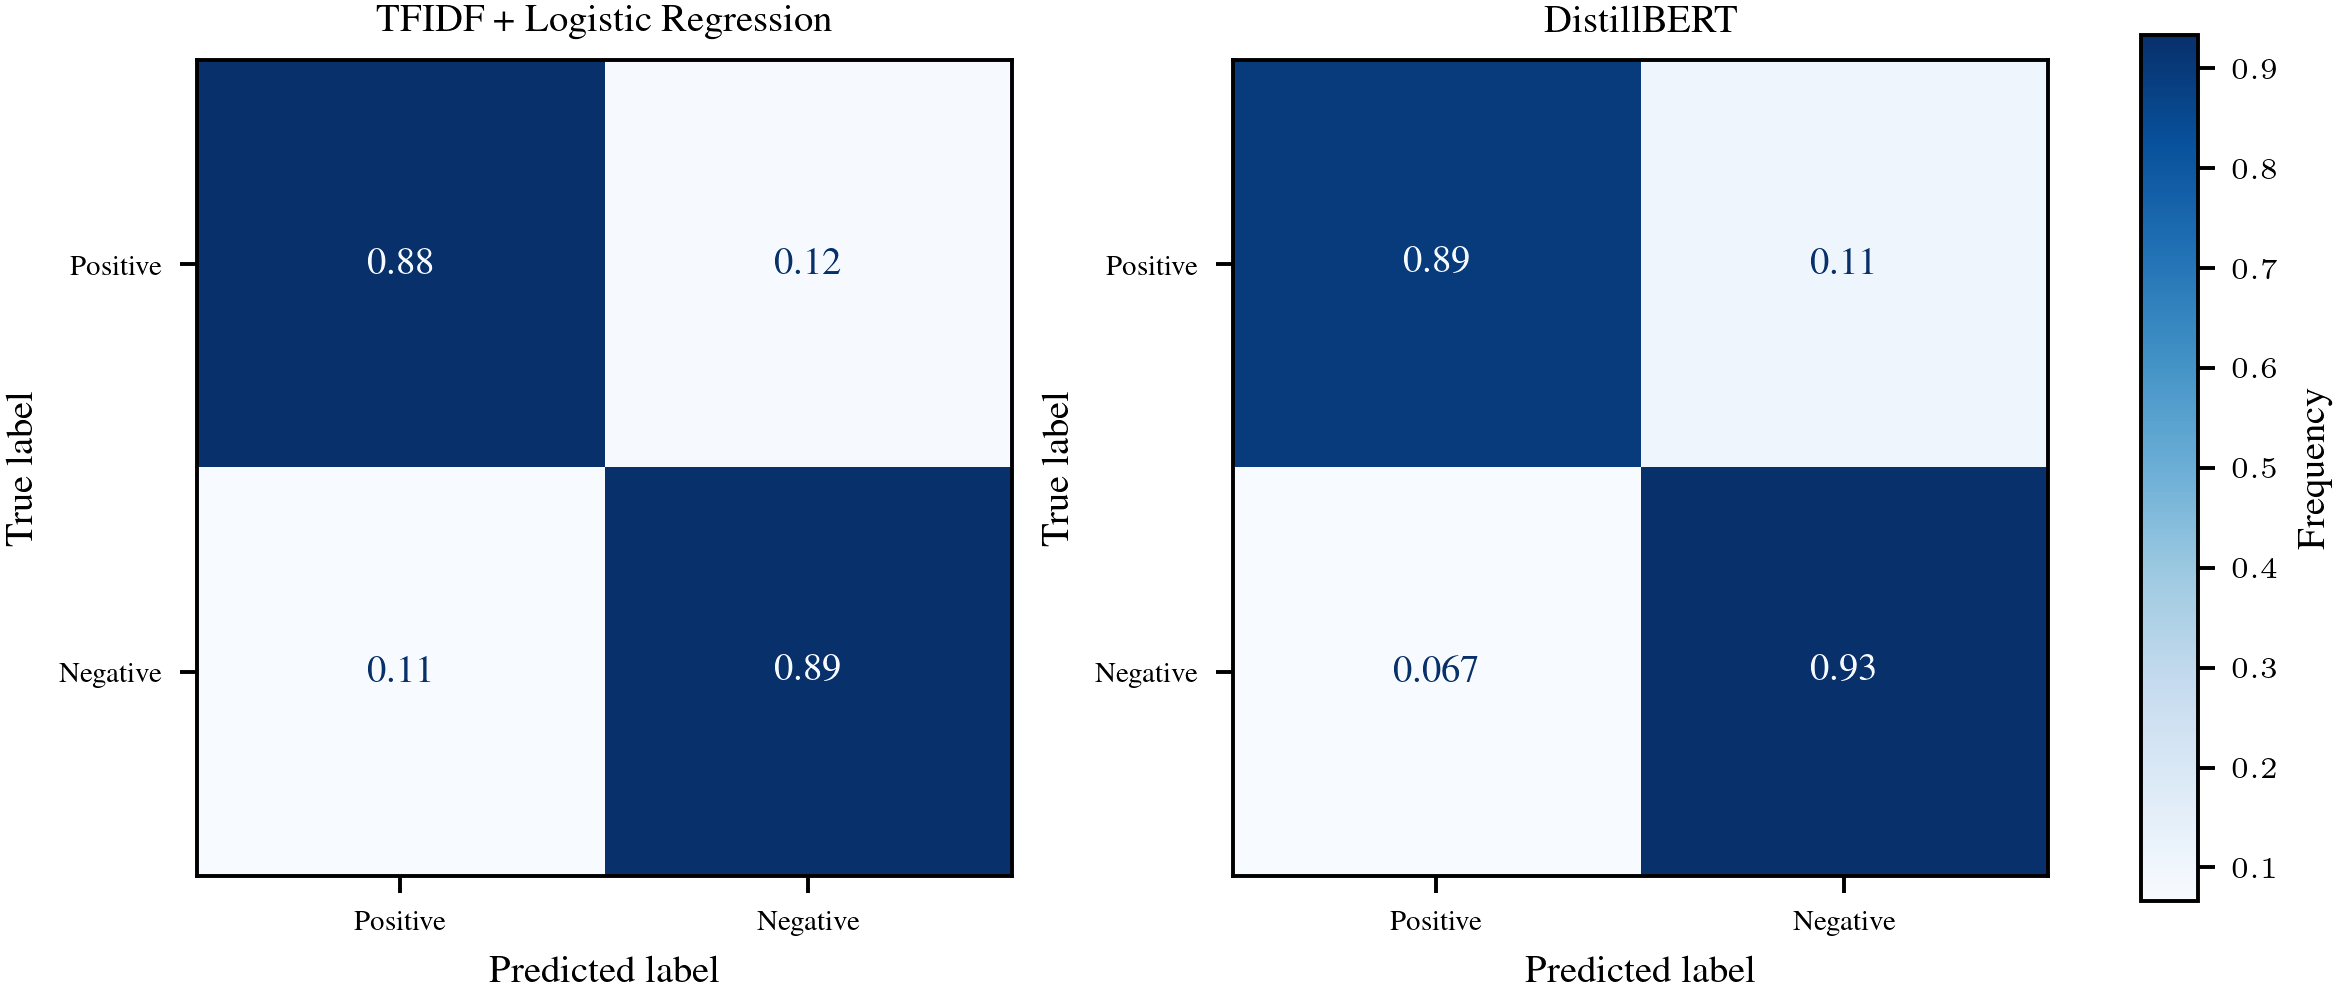

In [23]:
create_conf_matrix_for_model_comparison(y_test_m1, y_hat_m1, y_test_m2, y_hat_m2)